In [1]:
import os
import pandas as pd

# change dir
os.chdir(r'D:\code\github\strainOptimizer')

In [2]:
# load enzyme protein fraction 
df_enzyme_mass_fraction=pd.read_excel(r'reference\proYeast9\data\enzyme_fraction_based_on_total_protein_across_compartment.xlsx',index_col=1)
df_enzyme_mass_fraction=df_enzyme_mass_fraction.iloc[:,1:]
# load phenotype data
df_phenotype = pd.read_excel(r'reference\proYeast9\data\physiology_collection.xlsx',index_col=0)

# only choose batch condition proteomics dataset
selected_source=['sysbio_Francesca','sysbio_Johan','Joao A Paulo']
sampleList=df_phenotype[df_phenotype['source'].isin(selected_source)].index.tolist()

df_enzyme_mass_fraction=df_enzyme_mass_fraction[sampleList]

df_enzyme_mass_fraction.head()

,Glucose_phase_rep1(g/gDW),Glucose_phase_rep2(g/gDW),Glucose_phase_rep3(g/gDW),Diauxic_shift_rep1(g/gDW),Diauxic_shift_rep2(g/gDW),Diauxic_shift_rep3(g/gDW),Ethanol_phase_rep1(g/gDW),Ethanol_phase_rep2(g/gDW),Ethanol_phase_rep3(g/gDW),Min_aerobic_1,...,oleate(mmol/gDW),fructose(mmol/gDW),sucrose(mmol/gDW),trehalose(mmol/gDW),lactate(mmol/gDW),acetate(mmol/gDW),pryuvate(mmol/gDW),glycerol(mmol/gDW),galactose(mmol/gDW),raffinose(mmol/gDW)
compartment,,,,,,,,,,,,,,,,,,,,,
nucleus,1.181193e-01,1.169833e-01,1.178753e-01,7.627933e-02,7.537041e-02,7.795656e-02,7.265490e-02,7.430789e-02,7.481935e-02,0.055379,...,0.058038,0.055427,0.058553,0.058668,0.061703,0.046010,0.062349,0.058678,0.060975,0.055084
mitochondrion,2.422366e-01,2.402341e-01,2.414316e-01,3.080846e-01,3.116748e-01,3.129581e-01,3.061079e-01,3.053339e-01,3.033589e-01,0.215751,...,0.388809,0.251683,0.247437,0.415075,0.397251,0.454343,0.381355,0.415940,0.259236,0.312402
membrane,3.628402e-02,3.507878e-02,3.618985e-02,7.397013e-02,7.719238e-02,8.090709e-02,6.450059e-02,6.457521e-02,6.520626e-02,0.036365,...,0.066374,0.049519,0.050163,0.067711,0.064931,0.088735,0.071908,0.075594,0.063383,0.066289
bounding membrane of organelle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Golgi stack,5.650243e-08,7.341910e-08,6.638698e-08,1.591437e-07,1.204308e-07,1.947233e-07,5.043895e-07,3.535982e-07,2.872122e-07,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


C:\Users\wangh\AppData\Local\Temp\ipykernel_26372\3371627889.py:23: UserWarning: The palette list has more values (10) than needed (8), which may not be intended.
  sns.boxplot(data=data,ax=ax,showfliers=False,orient='h',palette=palette)
C:\Users\wangh\AppData\Local\Temp\ipykernel_26372\3371627889.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0,fontweight='bold',fontsize=12)


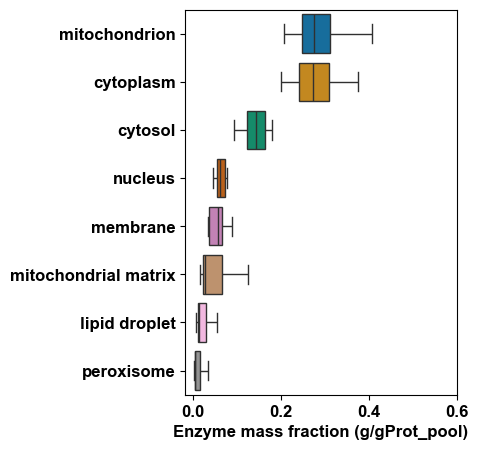

In [3]:
to_keep_compartment=['cytoplasm','mitochondrion','nucleus','lipid droplet','membrane','mitochondrial matrix','peroxisome','cytosol']
df_enzyme_mass_fraction=df_enzyme_mass_fraction[df_enzyme_mass_fraction.index.isin(to_keep_compartment)]

# plot the distribution for each compartment(rows)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# set fontstyle as Arial
plt.rcParams['font.family'] = 'Arial'
palette=sns.color_palette("colorblind")

data=df_enzyme_mass_fraction.T
# ignore columns with mean value < 0.05
data = data.loc[:, data.mean(axis=0) > 0.01]

# sort according to the mean value
data = data.reindex(data.mean().sort_values(ascending=False).index, axis=1)

fig,ax=plt.subplots(figsize=(3.5,5))

# plot the distribution for each compartment(rows), 横向绘制
sns.boxplot(data=data,ax=ax,showfliers=False,orient='h',palette=palette)

# rotate x tick
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,fontweight='bold',fontsize=12)
ax.set_ylabel('')
ax.set_xlabel('Enzyme mass fraction (g/gProt_pool)',fontweight='bold',fontsize=12)
# set y ticks: 0,0.2
ax.set_xticks(np.arange(0,0.8,0.2))
# set x ticks label
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold',fontsize=12)

# save it
# fig.savefig('organelle_level_resource_allocation_evaluation.png',dpi=300,bbox_inches='tight')
plt.show()


In [6]:
# save 
df_enzyme_mass_fraction.to_csv(r'D:\code\github\strainOptimizer\analysis_code/results/sce_enzyme_mass_fraction.csv')

In [10]:
data=df_enzyme_mass_fraction.T.describe()
df_subproteome_bounds=pd.DataFrame(index=data.columns,columns=['min','max'])
df_subproteome_bounds['min']=data.loc['min',:]
df_subproteome_bounds['max']=data.loc['max',:]

df_subproteome_bounds.head()
# save result
df_subproteome_bounds.to_csv(r'D:\code\github\strainOptimizer\analysis_code/sce_organelle_proteome_bounds.csv')
